### 210968001 - W4
### Ambar 

In [ ]:
pip install scipy

In [1]:
import pandas as pd
from scipy.spatial.distance import cdist
import numpy as np
import random
import matplotlib.pyplot as plt

C:\Users\User\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [4]:
def las_ele(file):
    return file.readline().strip().split()[-1]

In [5]:
def first(dimension):
    """
    Randomly generates a path which may or may not be the solution
    """
    a=list(range(1,dimension+1))
    random.shuffle(a)
    return a
def distance(tour,dimension,dist_mat):
    """
    Calculates the total distance of the tour using the distance matrix
    returns the negative of the result
    """
    dist=0
    for i in range(dimension-1):
        dist+=dist_mat[tour[i]-1][tour[i+1]-1]
    return -dist
    
def generate_neighbors(x,dimension,n=10):
    """
    n-number of neighbors are generated for a given path by reversing certain sections of the tour path
    """
    neighbors = []
    while len(neighbors) < n:
        i=np.random.randint(1,dimension-1)
        j=np.random.randint(i+1,dimension)
        neighbor = x.copy()
        neighbor[i:j] = neighbor[i:j][::-1]
        if neighbor not in neighbors:
            neighbors.append(neighbor)
    return neighbors

In [6]:
def classic_hillclimb(max_iter,dimension,dist_mat):
    """
    Classic hill clomber algorithm that return the first optimal solution encounterd
    """
    x=first(dimension)
    x_dist=distance(x,dimension,dist_mat)
    for iter in range(max_iter):
        neighbors=generate_neighbors(x,dimension) #Generate 10 neighbors
        for i in neighbors:
            if distance(i,dimension,dist_mat) > x_dist:
                x=i
                x_dist=distance(i,dimension,dist_mat)
                break
    return([x,x_dist])

In [7]:
def steep_hillclimb(max_iter,dimension,dist_mat):
    """
    Hill climber algorithm that returns the best of the optimal solutions
    """
    x=first(dimension)
    x_dist=distance(x,dimension,dist_mat)
    for iter in range(max_iter):
        neighbors=generate_neighbors(x,dimension,20) #Generate 20 neighbors
        for i in neighbors:
            if distance(i,dimension,dist_mat) > x_dist:
                x=i
                x_dist=distance(i,dimension,dist_mat)
    return([x,x_dist])

In [8]:
def stochastic_hillclimb(max_iter,dimension,dist_mat):
    """
    Hill climber algorithm that randomly returns a solution from the set of optimal solutions
    """
    x=first(dimension)
    x_dist=distance(x,dimension,dist_mat)
    for iter in range(max_iter):
        better_options=[]
        neighbors=generate_neighbors(x,dimension,20) #Generate 20 neighbors
        for i in neighbors:
            if distance(i,dimension,dist_mat) > x_dist:
                better_options.append(i)
        if len(better_options)>0:   
            random_index=random.randrange(0,len(better_options))
            x=better_options[random_index]
            x_dist=distance(x,dimension,dist_mat)
    return([x,x_dist])

In [9]:
def cols(lis):
    col=[]
    for row in lis:
        col.append(-row[1])
    return np.array(col)
#min max mean range variance std
def desc(arr):
    lis=[]
    arr=cols(arr)
    lis.append(np.amin(arr))
    lis.append(np.amax(arr))
    lis.append(np.mean(arr))
    lis.append(np.ptp(arr))
    lis.append(np.var(arr))
    lis.append(np.std(arr))
    return lis

In [10]:
def tsp(inp):
    file=open(inp)
    name=las_ele(file)
    file.readline()
    type=las_ele(file)
    dimension=int(las_ele(file))
    edge_weight=las_ele(file)
    file.readline()
    """
    The coordinates are read from the file and fed into a 2D List each row containing a x and y cordinate
    """
    cords=[]
    while True:
        cord=file.readline().strip().split()
        if len(cord) == 1:
            break;
        cords.append([float(cord[1]),float(cord[2])])
    file.close()
    """
    Using the previously obtained cordinates a distance matrix is prepared
    """
    df_array = np.array(cords)
    dist_mat = cdist(df_array, df_array)
    
    classic_scores=[]
    steephill_scores=[]
    stochastic_scores=[]
    for i in range(20):
        print("Iteration ",i+1)
        classic_scores.append(classic_hillclimb(50000,dimension,dist_mat))
        steephill_scores.append(steep_hillclimb(50000,dimension,dist_mat))
        stochastic_scores.append(stochastic_hillclimb(50000,dimension,dist_mat))
        print(" done...")
    #Classic
    cl_best_path,cl_distance=sorted(classic_scores,key=lambda scores:scores[1],reverse=True)[0]
    #Steep
    sp_best_path,sp_distance=sorted(steephill_scores,key=lambda scores:scores[1],reverse=True)[0]
    #Stochastic
    sc_best_path,sc_distance=sorted(stochastic_scores,key=lambda scores:scores[1],reverse=True)[0]
    
    print(f"""
    
    Classic
    
    Best path: {cl_best_path}
    Distance: {-cl_distance}
    
    Steep
    
    Best path: {sp_best_path} 
    Distance: {-sp_distance}
    
    Stochastic
    
    Best path: {sc_best_path}
    Distance: {-sc_distance}
    """)
    plt.bar(["Classic","Steep","Stochastic"],[cl_distance,sp_distance,sc_distance])
    plt.title("Results based on objective function")
    plt.show()
    df=[]
    df.append(desc(classic_scores))
    df.append(desc(steephill_scores))
    df.append(desc(stochastic_scores))
    print(pd.DataFrame(df,index=[["Classic","Steep","Stochastic"]],columns=[["Min","Max","Mean","Range","Variance","Std dev"]]))

Iteration  1
 done...
Iteration  2
 done...
Iteration  3
 done...
Iteration  4
 done...
Iteration  5
 done...
Iteration  6
 done...
Iteration  7
 done...
Iteration  8
 done...
Iteration  9
 done...
Iteration  10
 done...
Iteration  11
 done...
Iteration  12
 done...
Iteration  13
 done...
Iteration  14
 done...
Iteration  15
 done...
Iteration  16
 done...
Iteration  17
 done...
Iteration  18
 done...
Iteration  19
 done...
Iteration  20
 done...

    
    Classic
    
    Best path: [87, 62, 18, 1, 60, 8, 71, 68, 83, 51, 65, 90, 69, 15, 63, 86, 97, 67, 13, 49, 21, 75, 82, 85, 14, 12, 4, 32, 78, 20, 74, 26, 9, 17, 72, 70, 38, 54, 73, 46, 50, 92, 27, 56, 19, 37, 28, 93, 77, 59, 95, 94, 98, 66, 76, 58, 89, 2, 23, 84, 88, 31, 16, 45, 52, 100, 44, 35, 29, 96, 39, 55, 40, 43, 25, 24, 42, 7, 34, 41, 22, 30, 48, 80, 81, 91, 64, 36, 5, 61, 11, 57, 47, 99, 53, 6, 79, 3, 33, 10]
    Distance: 8179.501752863724
    
    Steep
    
    Best path: [61, 11, 36, 64, 91, 13, 67, 97, 63, 15, 86, 49, 21

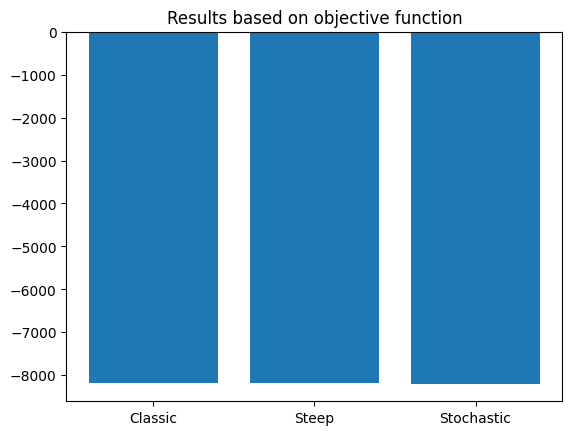

                    Min          Max         Mean        Range       Variance  \
Classic     8179.501753  9243.638551  8600.368893  1064.136798  108713.972102   
Steep       8191.546128  9329.834606  8649.279172  1138.288478   54985.934251   
Stochastic  8195.757322  9297.048322  8639.740926  1101.291000   90135.715894   

               Std dev  
Classic     329.718019  
Steep       234.490798  
Stochastic  300.226108  


In [11]:
tsp("rd100.tsp")

Iteration  1
 done...
Iteration  2
 done...
Iteration  3
 done...
Iteration  4
 done...
Iteration  5
 done...
Iteration  6
 done...
Iteration  7
 done...
Iteration  8
 done...
Iteration  9
 done...
Iteration  10
 done...
Iteration  11
 done...
Iteration  12
 done...
Iteration  13
 done...
Iteration  14
 done...
Iteration  15
 done...
Iteration  16
 done...
Iteration  17
 done...
Iteration  18
 done...
Iteration  19
 done...
Iteration  20
 done...

    
    Classic
    
    Best path: [101, 100, 99, 92, 91, 90, 109, 89, 81, 80, 82, 88, 84, 83, 76, 79, 94, 93, 98, 97, 96, 95, 78, 77, 75, 74, 73, 72, 71, 70, 69, 68, 67, 66, 65, 64, 63, 58, 57, 59, 44, 45, 46, 56, 55, 54, 47, 48, 53, 52, 51, 50, 49, 37, 38, 35, 39, 40, 41, 42, 43, 60, 61, 62, 118, 117, 115, 116, 86, 85, 87, 113, 114, 111, 112, 110, 108, 105, 104, 103, 102, 169, 168, 167, 166, 172, 171, 170, 173, 106, 107, 174, 162, 161, 175, 160, 159, 158, 157, 119, 120, 121, 122, 123, 124, 125, 30, 31, 34, 36, 33, 32, 29, 28, 27, 26, 22, 

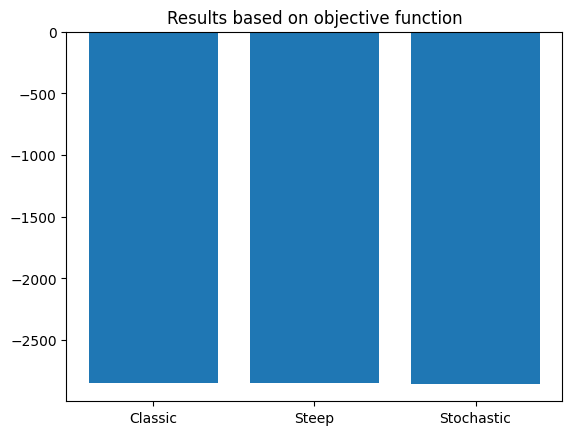

                    Min          Max         Mean       Range     Variance  \
Classic     2844.135263  3100.595720  2966.983471  256.460456  3700.650264   
Steep       2848.135619  3055.608063  2953.325976  207.472444  2826.761033   
Stochastic  2853.198930  3084.651044  2957.613098  231.452114  3902.968828   

              Std dev  
Classic     60.832970  
Steep       53.167293  
Stochastic  62.473745  


In [12]:
tsp("a280.tsp")

Iteration  1
 done...
Iteration  2
 done...
Iteration  3
 done...
Iteration  4
 done...
Iteration  5
 done...
Iteration  6
 done...
Iteration  7
 done...
Iteration  8
 done...
Iteration  9
 done...
Iteration  10
 done...
Iteration  11
 done...
Iteration  12
 done...
Iteration  13
 done...
Iteration  14
 done...
Iteration  15
 done...
Iteration  16
 done...
Iteration  17
 done...
Iteration  18
 done...
Iteration  19
 done...
Iteration  20
 done...

    
    Classic
    
    Best path: [105, 111, 16, 133, 77, 122, 14, 80, 78, 15, 59, 79, 121, 88, 94, 10, 113, 63, 48, 3, 62, 149, 22, 125, 21, 115, 150, 104, 4, 45, 128, 68, 119, 91, 106, 71, 44, 64, 112, 145, 136, 13, 74, 123, 31, 27, 129, 144, 147, 49, 72, 23, 38, 32, 131, 67, 109, 43, 116, 101, 41, 39, 57, 117, 140, 60, 66, 17, 130, 148, 11, 61, 36, 69, 127, 118, 24, 12, 53, 40, 139, 47, 120, 42, 9, 28, 6, 37, 2, 19, 99, 114, 102, 108, 70, 137, 132, 55, 58, 50, 135, 86, 29, 81, 110, 51, 20, 25, 141, 65, 85, 142, 18, 75, 26, 146, 56, 83, 

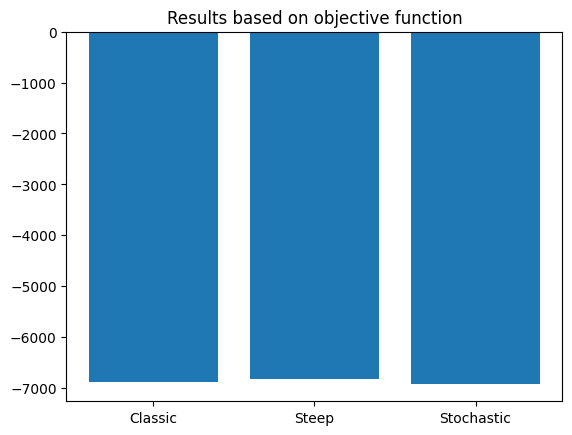

                    Min          Max         Mean       Range      Variance  \
Classic     6884.514777  7513.995996  7194.807824  629.481219  27906.021707   
Steep       6824.139097  7409.807732  7193.773461  585.668635  20724.004392   
Stochastic  6915.328125  7537.781373  7249.911666  622.453248  26674.170328   

               Std dev  
Classic     167.050955  
Steep       143.958343  
Stochastic  163.322290  


In [13]:
tsp("ch150.tsp")

Iteration  1
 done...
Iteration  2
 done...
Iteration  3
 done...
Iteration  4
 done...
Iteration  5
 done...
Iteration  6
 done...
Iteration  7
 done...
Iteration  8
 done...
Iteration  9
 done...
Iteration  10
 done...
Iteration  11
 done...
Iteration  12
 done...
Iteration  13
 done...
Iteration  14
 done...
Iteration  15
 done...
Iteration  16
 done...
Iteration  17
 done...
Iteration  18
 done...
Iteration  19
 done...
Iteration  20
 done...

    
    Classic
    
    Best path: [181, 183, 176, 173, 174, 175, 177, 178, 179, 194, 198, 197, 196, 195, 186, 193, 192, 187, 185, 180, 184, 188, 191, 190, 189, 182, 168, 167, 108, 109, 110, 111, 118, 119, 120, 124, 169, 125, 131, 130, 126, 170, 127, 129, 136, 135, 133, 132, 134, 140, 142, 141, 143, 147, 146, 145, 144, 150, 151, 137, 128, 171, 172, 166, 165, 164, 163, 162, 161, 152, 149, 148, 153, 160, 159, 158, 157, 156, 155, 154, 139, 138, 123, 121, 122, 115, 116, 117, 112, 107, 106, 113, 114, 105, 104, 103, 102, 93, 94, 101, 95, 96, 90, 

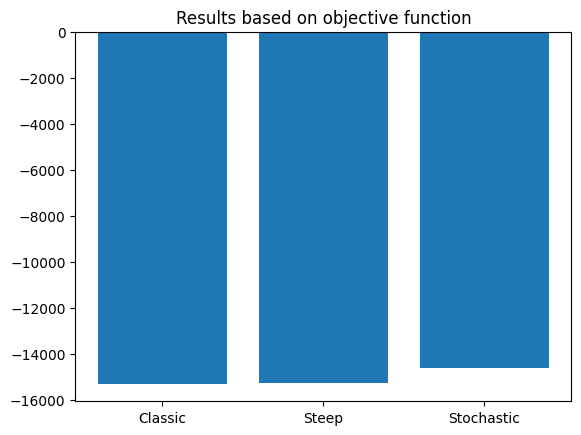

                     Min           Max          Mean        Range  \
Classic     15281.421342  16943.960543  16173.265830  1662.539201   
Steep       15251.018930  17280.642993  16356.394584  2029.624063   
Stochastic  14600.842993  16965.433371  16220.297587  2364.590378   

                 Variance     Std dev  
Classic     321364.385965  566.890100  
Steep       288472.365857  537.096235  
Stochastic  378701.749262  615.387479  


In [14]:
tsp("d198.tsp")

Iteration  1
 done...
Iteration  2
 done...
Iteration  3
 done...
Iteration  4
 done...
Iteration  5
 done...
Iteration  6
 done...
Iteration  7
 done...
Iteration  8
 done...
Iteration  9
 done...
Iteration  10
 done...
Iteration  11
 done...
Iteration  12
 done...
Iteration  13
 done...
Iteration  14
 done...
Iteration  15
 done...
Iteration  16
 done...
Iteration  17
 done...
Iteration  18
 done...
Iteration  19
 done...
Iteration  20
 done...

    
    Classic
    
    Best path: [91, 44, 14, 38, 86, 16, 61, 85, 93, 59, 99, 96, 6, 94, 13, 58, 53, 101, 27, 52, 89, 18, 83, 60, 5, 84, 17, 45, 46, 8, 82, 7, 48, 47, 36, 49, 64, 63, 90, 32, 10, 70, 30, 51, 20, 66, 65, 71, 35, 34, 78, 9, 81, 33, 79, 3, 77, 68, 80, 29, 24, 54, 4, 55, 25, 39, 67, 23, 56, 75, 22, 41, 15, 43, 42, 100, 98, 37, 92, 95, 97, 87, 57, 2, 73, 74, 72, 21, 40, 26, 28, 12, 76, 50, 1, 69, 31, 88, 62, 19, 11]
    Distance: 662.631544468059
    
    Steep
    
    Best path: [29, 24, 54, 26, 28, 76, 12, 80, 68, 77, 3, 79,

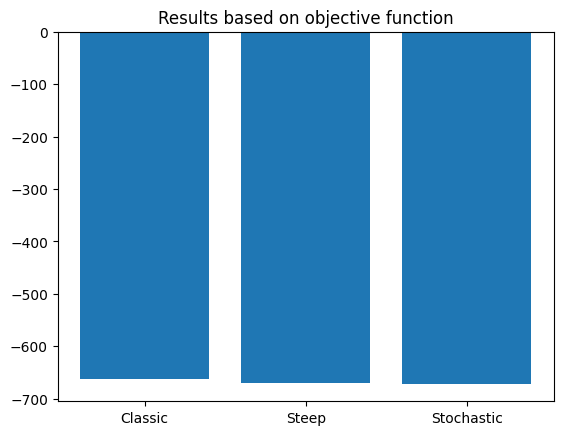

                   Min         Max        Mean      Range    Variance  \
Classic     662.631544  702.377035  685.851445  39.745490  119.876056   
Steep       670.012628  708.904309  689.284934  38.891681  135.155439   
Stochastic  671.346705  717.470134  687.462563  46.123429  121.459811   

              Std dev  
Classic     10.948792  
Steep       11.625637  
Stochastic  11.020881  


In [15]:
tsp("eil101.tsp")

In [16]:
"""
With 20 iterations of each data the results are mixed 
"""

'\nFor most datasets the stochastic hill climbing produces better results\n'